# VISUALS

### IMPORTS

In [17]:
import os

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

### 1

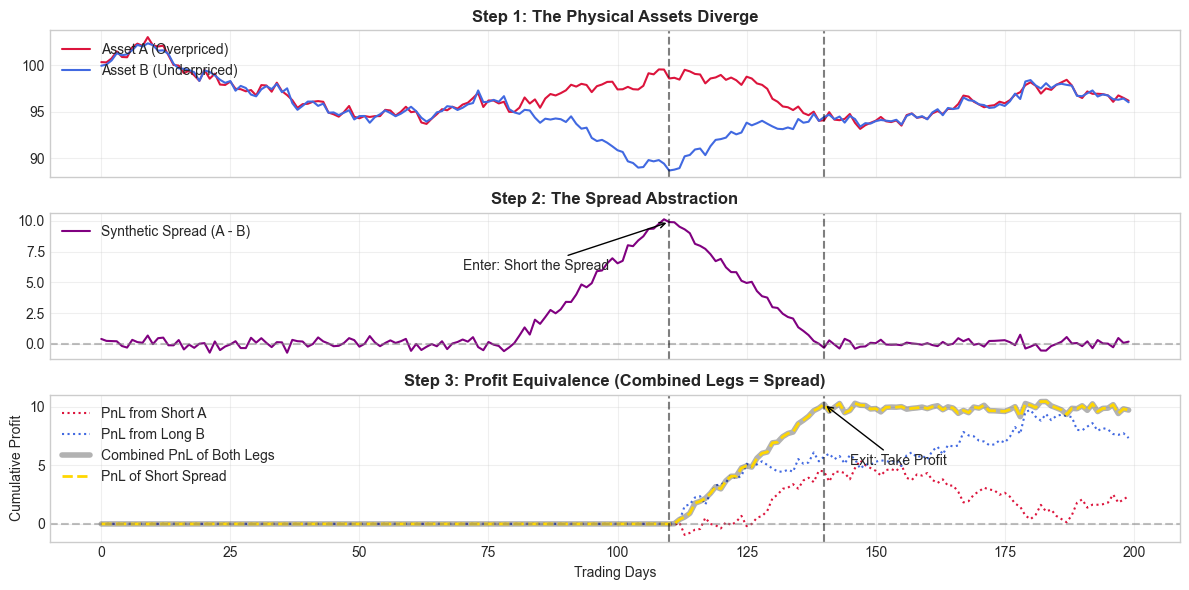

In [18]:


# Set plotting style for a clean, professional report look
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# 1. Simulate the Data
# ---------------------------------------------------------
np.random.seed(42)
n_steps = 200
time = np.arange(n_steps)

# Create a common random walk (the baseline market movement)
common_factor = np.cumsum(np.random.randn(n_steps) * 0.5) + 100

# Create Asset A and Asset B (highly correlated, tracking the common factor)
asset_a = common_factor + np.random.randn(n_steps) * 0.2
asset_b = common_factor + np.random.randn(n_steps) * 0.2

# Force a divergence (Spread Blowout) from day 80 to day 110
divergence = np.zeros(n_steps)
divergence[80:110] = np.linspace(0, 5, 30)
# Force a mean-reversion from day 110 to day 140
divergence[110:140] = np.linspace(5, 0, 30)

# Apply the divergence so Asset A goes up and Asset B goes down
asset_a += divergence
asset_b -= divergence

# Calculate the Spread
spread = asset_a - asset_b

# ---------------------------------------------------------
# 2. Simulate the Trading PnL
# ---------------------------------------------------------
entry_day = 110  # Maximum divergence
exit_day = 140   # Fully reverted

# PnL tracking arrays
pnl_a = np.zeros(n_steps)
pnl_b = np.zeros(n_steps)
pnl_spread = np.zeros(n_steps)

# We short A, long B, which is equivalent to shorting the Spread
for t in range(entry_day, n_steps):
    pnl_a[t] = -(asset_a[t] - asset_a[entry_day]) # Short Asset A
    pnl_b[t] =  (asset_b[t] - asset_b[entry_day]) # Long Asset B
    pnl_spread[t] = -(spread[t] - spread[entry_day]) # Short Spread

total_leg_pnl = pnl_a + pnl_b

# ---------------------------------------------------------
# 3. Plotting the Report Graphic
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Panel 1: Physical Legs (Asset A and Asset B)
axes[0].plot(time, asset_a, label='Asset A (Overpriced)', color='crimson')
axes[0].plot(time, asset_b, label='Asset B (Underpriced)', color='royalblue')
axes[0].axvline(entry_day, color='k', linestyle='--', alpha=0.5)
axes[0].axvline(exit_day, color='k', linestyle='--', alpha=0.5)
axes[0].annotate('Enter: Short A, Long B', xy=(entry_day, 105), xytext=(entry_day-35, 108),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[0].set_title('Step 1: The Physical Assets Diverge', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')

# Panel 2: The Synthetic Spread
axes[1].plot(time, spread, color='purple', label='Synthetic Spread (A - B)')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(entry_day, color='k', linestyle='--', alpha=0.5)
axes[1].axvline(exit_day, color='k', linestyle='--', alpha=0.5)
axes[1].annotate('Enter: Short the Spread', xy=(entry_day, spread[entry_day]), xytext=(entry_day-40, 6),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1].set_title('Step 2: The Spread Abstraction', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')

# Panel 3: PnL Equivalence
# We plot the individual legs, and then show that the sum equals the spread PnL
axes[2].plot(time, pnl_a, color='crimson', linestyle=':', label='PnL from Short A')
axes[2].plot(time, pnl_b, color='royalblue', linestyle=':', label='PnL from Long B')
axes[2].plot(time, total_leg_pnl, color='black', linewidth=4, alpha=0.3, label='Combined PnL of Both Legs')
axes[2].plot(time, pnl_spread, color='gold', linestyle='--', linewidth=2, label='PnL of Short Spread')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(entry_day, color='k', linestyle='--', alpha=0.5)
axes[2].axvline(exit_day, color='k', linestyle='--', alpha=0.5)
axes[2].annotate('Exit: Take Profit', xy=(exit_day, pnl_spread[exit_day]), xytext=(exit_day+5, 5),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[2].set_title('Step 3: Profit Equivalence (Combined Legs = Spread)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Trading Days')
axes[2].set_ylabel('Cumulative Profit')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig('../plots/eda/long-short.pdf')
plt.show()

### 2

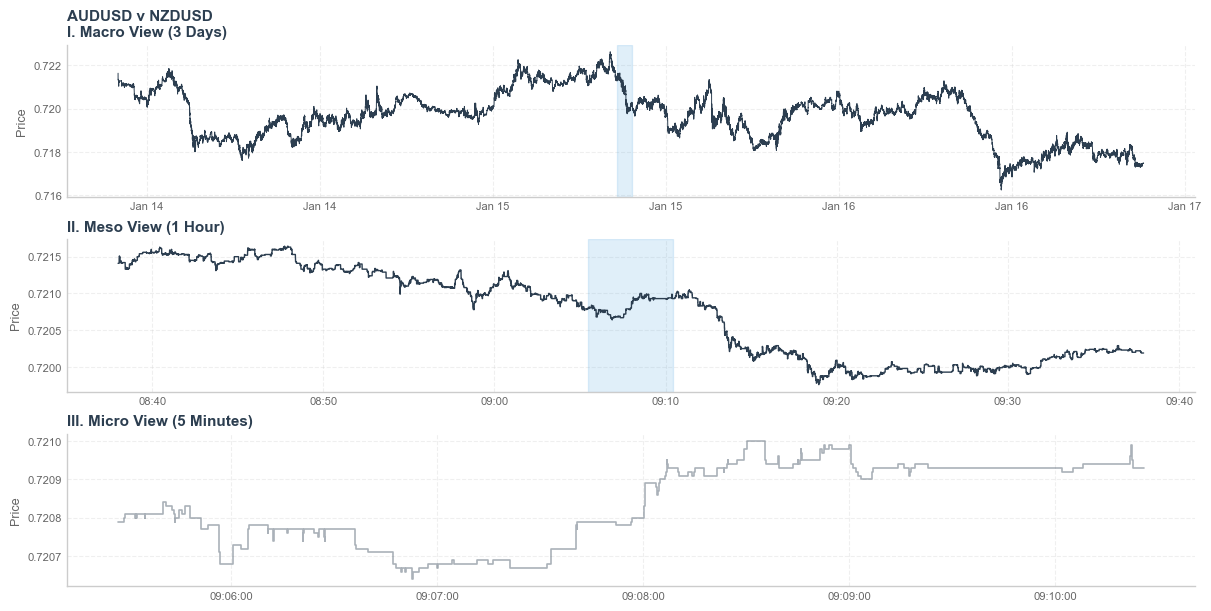

In [19]:
# --- Visual Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Inter', 'Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Minimalist Palette
MAIN_COLOR = '#2c3e50'  # Deep Slate
ACCENT_COLOR = '#3498db' # Muted Blue for zoom regions
TICK_COLOR = '#e74c3c'   # Muted Red for individual ticks
SPAN_ALPHA = 0.15

file_path = '../data/processed/audusd_dukascopy_ask_201901.parquet'

# 1. Load/Simulate (Same logic as before)
if os.path.exists(file_path):
    df = pd.read_parquet(file_path)
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
    df = df.sort_index()
else:
    n_ticks = 100000
    time_deltas = np.random.exponential(scale=2.5, size=n_ticks)
    timestamps = pd.Timestamp('2019-01-02 00:00:00', tz='UTC') + pd.to_timedelta(np.cumsum(time_deltas), unit='s')
    prices = 0.7000 + np.cumsum(np.random.choice([-0.0001, 0.0001, 0.0], size=n_ticks, p=[0.3, 0.3, 0.4]))
    df = pd.DataFrame({'price': prices}, index=timestamps)

# 2. Slicing
anchor_time = df.index[len(df) // 2]
windows = {
    'macro': (anchor_time - pd.Timedelta(days=1.5), anchor_time + pd.Timedelta(days=1.5)),
    'meso': (anchor_time - pd.Timedelta(minutes=30), anchor_time + pd.Timedelta(minutes=30)),
    'micro': (anchor_time - pd.Timedelta(minutes=2.5), anchor_time + pd.Timedelta(minutes=2.5))
}

# 3. Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 6), constrained_layout=True)

# Panel 1: Macro
ax = axes[0]
df_macro = df.loc[windows['macro'][0]:windows['macro'][1]]
ax.plot(df_macro.index, df_macro['price'], color=MAIN_COLOR, linewidth=0.7)
ax.axvspan(*windows['meso'], color=ACCENT_COLOR, alpha=SPAN_ALPHA)
ax.set_title('AUDUSD v NZDUSD\nI. Macro View (3 Days)', loc='left', fontsize=11, fontweight='bold', color=MAIN_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Panel 2: Meso
ax = axes[1]
df_meso = df.loc[windows['meso'][0]:windows['meso'][1]]
ax.plot(df_meso.index, df_meso['price'], color=MAIN_COLOR, linewidth=1, drawstyle='steps-post')
ax.axvspan(*windows['micro'], color=ACCENT_COLOR, alpha=SPAN_ALPHA)
ax.set_title('II. Meso View (1 Hour)', loc='left', fontsize=11, fontweight='bold', color=MAIN_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Panel 3: Micro
ax = axes[2]
df_micro = df.loc[windows['micro'][0]:windows['micro'][1]]

# The line below draws the "steps-post" blue/gray line
ax.plot(df_micro.index, df_micro['price'], color=MAIN_COLOR, linewidth=1.2, drawstyle='steps-post', alpha=0.4)

# ---> DELETE OR COMMENT OUT THIS LINE <---
# ax.scatter(df_micro.index, df_micro['price'], s=8, color=TICK_COLOR, alpha=0.8, label='Tick Arrival')

ax.set_title('III. Micro View (5 Minutes)', loc='left', fontsize=11, fontweight='bold', color=MAIN_COLOR)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# General Cleanup
for i, ax in enumerate(axes):
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    # Clean up labels
    ax.set_ylabel('Price', fontsize=9, color='#666666')
    ax.tick_params(axis='both', which='major', labelsize=8, colors='#666666')
    
    if i < 2: # Remove x-labels for top two for cleaner look
        ax.set_xlabel('')

# # Annotation for Micro View (simplified)
# mid_idx = len(df_micro) // 2
# axes[2].annotate('Asynchronous Arrivals', 
#                  xy=(df_micro.index[mid_idx], df_micro['price'].iloc[mid_idx]),
#                  xytext=(10, 10), textcoords='offset points',
#                  fontsize=8, color=MAIN_COLOR,
#                  arrowprops=dict(arrowstyle='->', color=MAIN_COLOR, lw=0.5))

# Save
os.makedirs('../plots/eda', exist_ok=True)
plt.savefig('../plots/eda/high_frequency_minimal.pdf', bbox_inches='tight', dpi=300)
plt.show()

### 3

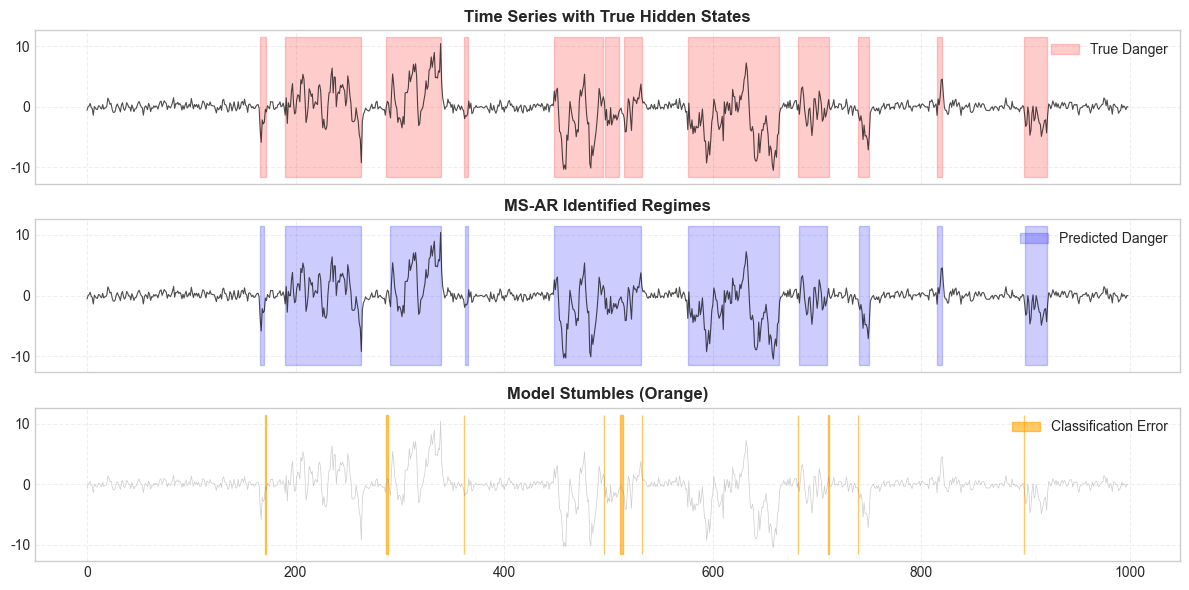

In [20]:
np.random.seed(42)
N = 1000

# 1. Simulate Regimes
# P[i, j] = Prob(next state = j | current state = i)
P = np.array([[0.98, 0.02], [0.05, 0.95]])
phi = np.array([0.3, 0.9])    # State 0: Quick mean reversion; State 1: Random walk
sigma = np.array([0.5, 2.0])  # State 0: Low vol; State 1: High vol

states = np.zeros(N, dtype=int)
y = np.zeros(N)

for t in range(1, N):
    states[t] = np.random.choice([0, 1], p=P[states[t-1]])
    s = states[t]
    y[t] = phi[s] * y[t-1] + sigma[s] * np.random.randn()

# 2. Fit MS-AR
model = MarkovAutoregression(y, k_regimes=2, order=1, switching_ar=True, switching_variance=True)
res = model.fit(search_reps=20, disp=False)

# 3. Process Predictions
# Match labels by variance to handle label switching
params = dict(zip(res.model.param_names, res.params))
danger_state = 1 if params['sigma2[1]'] > params['sigma2[0]'] else 0

probs = res.smoothed_marginal_probabilities
if isinstance(probs, pd.DataFrame): probs = probs.values
pred_states = (probs[:, danger_state] > 0.5).astype(int)

# Align true states (AR(1) drops first observation)
true_states = states[1:]
y_plot = y[1:]
is_correct = (pred_states == true_states)

# 4. Plotting the Comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Panel 1: True Regimes
axes[0].plot(y_plot, color='black', lw=0.8, alpha=0.7)
axes[0].fill_between(range(len(y_plot)), axes[0].get_ylim()[0], axes[0].get_ylim()[1], 
                    where=(true_states==1), color='red', alpha=0.2, label='True Danger')
axes[0].set_title('Time Series with True Hidden States', fontweight='bold')

# Panel 2: Predicted Regimes
axes[1].plot(y_plot, color='black', lw=0.8, alpha=0.7)
axes[1].fill_between(range(len(y_plot)), axes[1].get_ylim()[0], axes[1].get_ylim()[1], 
                    where=(pred_states==1), color='blue', alpha=0.2, label='Predicted Danger')
axes[1].set_title('MS-AR Identified Regimes', fontweight='bold')

# Panel 3: Classification Errors
axes[2].plot(y_plot, color='gray', lw=0.5, alpha=0.4)
axes[2].fill_between(range(len(y_plot)), axes[2].get_ylim()[0], axes[2].get_ylim()[1], 
                    where=(~is_correct), color='orange', alpha=0.6, label='Classification Error')
axes[2].set_title(f'Model Stumbles (Orange)', fontweight='bold')

for ax in axes: ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../plots/eda/true-and-hidden-states.pdf')
plt.show()